<!-- <p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3> -->


В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 60

%matplotlib inline  

sns.set_theme(style='darkgrid', font_scale=1.2)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}')

Using cuda


## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [3]:
import kagglehub
import shutil

PATH = 'dataset'
os.makedirs(PATH, exist_ok=True)

In [4]:
images_path = kagglehub.dataset_download("tommykamaz/faces-dataset-small")

if os.path.exists(images_path):
    for item in os.listdir(images_path):
        src = os.path.join(images_path, item)
        dst = os.path.join(PATH, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

In [5]:
def get_dataloader(image_size, batch_size):
    """
    Builds dataloader for training data.
    Use tt.Compose and tt.Resize for transformations
    :param image_size: height and wdith of the image
    :param batch_size: batch_size of the dataloader
    :returns: DataLoader object
    """
    transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor(),
        tt.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    dataset = ImageFolder(root='dataset/', transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

    return dataloader 

In [6]:
image_size = 128
batch_size = 64

train_loader = get_dataloader(image_size, batch_size)

print(f'Изображений: {len(train_loader.dataset)}')

Изображений: 3143


In [7]:
def denorm(img_tensors):
    return img_tensors * 0.5 + 0.5

def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1, 2, 0))

def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

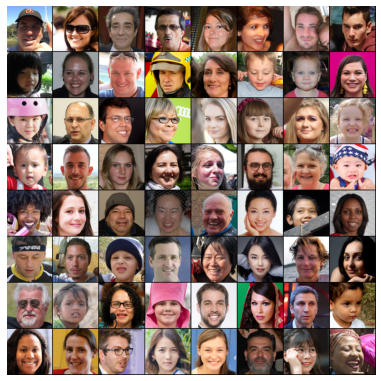

In [8]:
# Примеры реальных изображений

show_batch(train_loader)
plt.show();

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [9]:
# Инициализация весов

def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [10]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.main(x)

In [11]:
class Generator(nn.Module):
    def __init__(self, latent_size=256):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_size, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    
    def forward(self, x):
        return self.main(x)

In [12]:
latent_size = 256

discriminator = Discriminator().to(device)
generator = Generator(latent_size).to(device)

discriminator.apply(weights_init)
generator.apply(weights_init)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(256, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), paddin

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [13]:
lr = 0.0002

beta_1 = 0.5
beta_2 = 0.999

model = {
    'discriminator': discriminator,
    'generator': generator
}

criterion = {
    'discriminator': nn.BCELoss(),
    'generator': nn.BCELoss()
}

optimizer = {
    'discriminator': torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta_1, beta_2)),
    'generator': torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta_1, beta_2))
}

In [14]:
def fit(model, criterion, epochs, optimizer, train_loader, latent_size, device):
    discriminator = model['discriminator']
    generator = model['generator']
    
    optimizer_discriminator = optimizer['discriminator']
    optimizer_generator = optimizer['generator']
    
    losses_d = []
    losses_g = []
    
    fixed_noise = torch.randn(16, latent_size, 1, 1, device=device)
    
    for epoch in range(epochs):
        loss_d_epoch = 0.0
        loss_g_epoch = 0.0
        
        for real_imgs, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            bs = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            
            real_labels = torch.full((bs, 1), 0.9, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)
            
            # Тренировка дискриминатора
            optimizer_discriminator.zero_grad()
            
            # real
            pred_real = discriminator(real_imgs)
            loss_real = criterion['discriminator'](pred_real, real_labels)
            
            # fake
            noise = torch.randn(bs, latent_size, 1, 1, device=device)
            fake_imgs = generator(noise).detach()
            pred_fake = discriminator(fake_imgs)
            loss_fake = criterion['discriminator'](pred_fake, fake_labels)
            
            loss_d = loss_real + loss_fake
            loss_d.backward()
            optimizer_discriminator.step()
            
            # Тренировка генератора
            optimizer_generator.zero_grad()
            
            noise = torch.randn(bs, latent_size, 1, 1, device=device)
            fake_imgs = generator(noise)
            pred_fake = discriminator(fake_imgs)
            loss_g = criterion['generator'](pred_fake, real_labels)
            
            loss_g.backward()
            optimizer_generator.step()
            
            loss_d_epoch += loss_d.item()
            loss_g_epoch += loss_g.item()
        
        losses_d.append(loss_d_epoch / len(train_loader))
        losses_g.append(loss_g_epoch / len(train_loader))

        if (epoch + 1) in range(1, 11) or (epoch + 1) % 50 == 0: # 50
            print(f'Epoch {epoch+1}/{epochs} | Loss G: {losses_g[-1]:.4f} | Loss D: {losses_d[-1]:.4f}')
        
        # Визуализация на эпохе 10 и каждые 100 эпох
        if (epoch + 1) == 10 or (epoch + 1) % 100 == 0: # 100
            generator.eval()
            with torch.no_grad():
                fake_samples = generator(fixed_noise).cpu()
                grid = make_grid(fake_samples * 0.5 + 0.5, nrow=4, padding=2)
                plt.figure(figsize=(6,6))
                plt.imshow(grid.permute(1,2,0))
                plt.axis('off')
                plt.title(f'Epoch {epoch+1}')
                plt.show()
            generator.train()
    
    return losses_d, losses_g

Epoch 1/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 1/500 | Loss G: 3.0720 | Loss D: 0.8338


Epoch 2/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 2/500 | Loss G: 4.3602 | Loss D: 0.5003


Epoch 3/500:   0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch 8/500 | Loss G: 4.4395 | Loss D: 0.7085


Epoch 9/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 9/500 | Loss G: 2.8286 | Loss D: 0.8750


Epoch 10/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 10/500 | Loss G: 2.8345 | Loss D: 0.7733


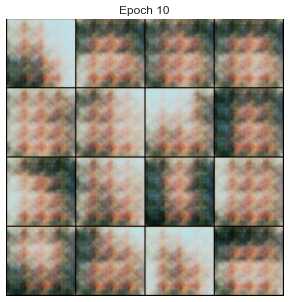

Epoch 11/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 12/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 13/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 14/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 15/500:   0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch 97/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 98/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 99/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 100/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 100/500 | Loss G: 2.8569 | Loss D: 0.6872


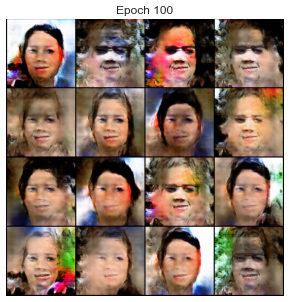

Epoch 101/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 102/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 103/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 104/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 105/500:   0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch 197/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 198/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 199/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 200/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 200/500 | Loss G: 2.8879 | Loss D: 0.7262


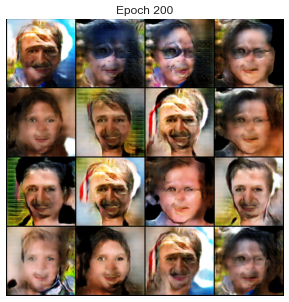

Epoch 201/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 202/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 203/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 204/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 205/500:   0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch 297/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 298/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 299/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 300/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 300/500 | Loss G: 2.9060 | Loss D: 0.5646


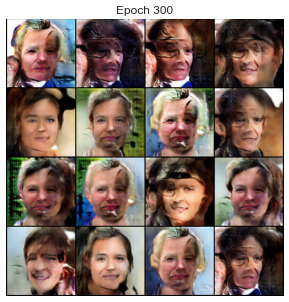

Epoch 301/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 302/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 303/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 304/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 305/500:   0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch 397/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 398/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 399/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 400/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 400/500 | Loss G: 3.1513 | Loss D: 0.5734


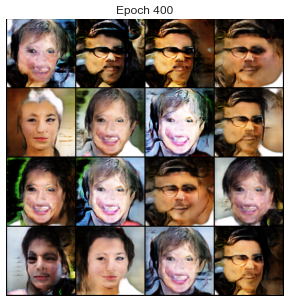

Epoch 401/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 402/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 403/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 404/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 405/500:   0%|          | 0/49 [00:00<?, ?it/s]

...

Epoch 497/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 498/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 499/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 500/500:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 500/500 | Loss G: 3.1656 | Loss D: 0.5381


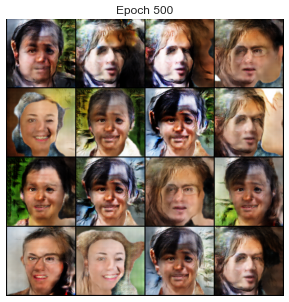

In [15]:
EPOCHS = 500

losses_d, losses_g = fit(
    model=model,
    criterion=criterion,
    epochs=EPOCHS,
    optimizer=optimizer,
    train_loader=train_loader,
    latent_size=latent_size,
    device=device
)

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

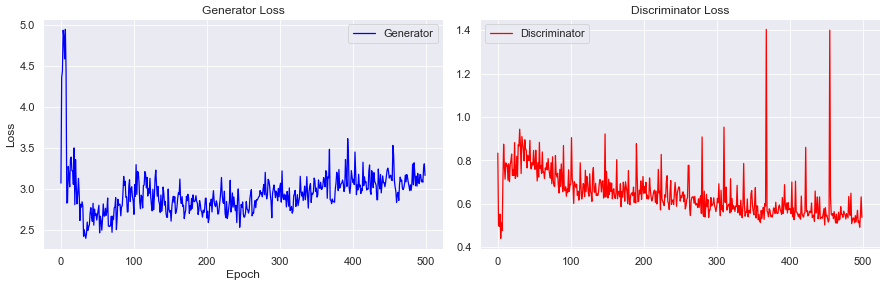

In [16]:
# Графики лоссов

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Генератор
ax1.plot(losses_g, label='Generator', color='blue')
ax1.set_title('Generator Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Дискриминатор
ax2.plot(losses_d, label='Discriminator', color='red')
ax2.set_title('Discriminator Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax2.legend()

plt.grid(True)
plt.tight_layout()

plt.show();

Дискриминатор быстро обучается различать сгенерированные изображения от реальных, что видно по графику лосса дискриминатора. Первые несколько эпох лосс дискриминатора резко снижается.  
Генератор в первые эпохи создает сильно шумные изображения, лосс его сначала растет и держиться несколько эпох на высоких значениях лосса. Далее генератор начинает создавать более правдоподобные менее шумные изображения, лосс на графике лосса генератора начинает снижаться, а затем плавно увеличивается. Возможно, что перееобучаться начинает.

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [17]:
n_images = 8

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)

generator.eval()
with torch.no_grad():
    fake_images = generator(fixed_latent)

In [18]:
def show_images(generated):
    generated = (generated + 1) / 2   # денормализация
    generated = generated.detach().cpu()
    grid = make_grid(generated, nrow=4, padding=2)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1,2,0))
    plt.axis('off')

    plt.show();

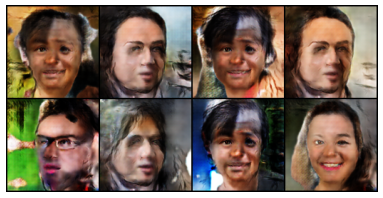

In [19]:
show_images(fake_images)

Как вам качество получившихся изображений?

Сгенерированные изображения имеются артефакты.  
Есть похожии лица, мало разнообразия.
Однако основные элементы лица на месте, поянтно что сгенерировали именно лица ☺.  
Нормально, но есть что улучшать.

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut

In [21]:
def compute_1nn_loo_accuracy(generator, train_loader, latent_size, device, max_samples=500):
    generator.eval()

    # Загрузка реальных изображений
    real_imgs_list = []
    for imgs, _ in tqdm(train_loader, desc='Загрузка реальных изображений'):
        real_imgs_list.append(imgs.cpu())
    real_imgs = torch.cat(real_imgs_list, dim=0)
    if max_samples:
        real_imgs = real_imgs[:max_samples]
    n = real_imgs.size(0)

    # Генерация фейковых изображений
    fake_imgs_list = []
    with torch.no_grad():
        for i in tqdm(range(0, n, batch_size), desc='Генерация фейковых изображений'):
            cur_bs = min(batch_size, n - i)
            noise = torch.randn(cur_bs, latent_size, 1, 1, device=device)
            fake_imgs_list.append(generator(noise).cpu())
    fake_imgs = torch.cat(fake_imgs_list, dim=0)[:n]

    real_flat = real_imgs.view(n, -1).numpy()
    fake_flat = fake_imgs.view(n, -1).numpy()

    X = np.concatenate([real_flat, fake_flat], axis=0)
    y = np.array([1]*n + [0]*n)                         # 1 - реальное, 0 - фейковое

    # Leave-One-Out с 1NN
    loo = LeaveOneOut()
    knn = KNeighborsClassifier(n_neighbors=1)
    correct = 0
    total = 0
    
    for train_idx, test_idx in tqdm(loo.split(X), total=len(X), desc='LOO классификация'):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        knn.fit(X_train, y_train)
        pred = knn.predict(X_test)
        if pred[0] == y_test[0]:
            correct += 1
        total += 1
    accuracy = correct / total

    print(f'1-NN LOO accuracy: {accuracy:.4f}')
    
    return accuracy

In [22]:
ACC_SAMPLES = 500

acc = compute_1nn_loo_accuracy(generator, train_loader, latent_size, device, max_samples=ACC_SAMPLES)

Загрузка реальных изображений:   0%|          | 0/49 [00:00<?, ?it/s]

Генерация фейковых изображений:   0%|          | 0/8 [00:00<?, ?it/s]

LOO классификация:   0%|          | 0/1000 [00:00<?, ?it/s]

1-NN LOO accuracy: 0.8580


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

В идеале необходимо получить точноть 0.5, что означало бы максимальную неуверенность в классификации реальных и фековых изображений.  
Пока что точность довольно велика. Различия между реальными и фековыми изображениями ощутима и различима, что и отображает метрика.

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

In [23]:
from sklearn.manifold import TSNE

In [24]:
def plot_tsne(generator, train_loader, latent_size, device, max_samples=500):
    generator.eval()
    real_imgs_list = []
    for imgs, _ in train_loader:
        real_imgs_list.append(imgs.cpu())
    real_imgs = torch.cat(real_imgs_list, dim=0)[:max_samples]
    n = real_imgs.size(0)

    fake_imgs_list = []
    with torch.no_grad():
        for i in range(0, n, batch_size):
            cur_bs = min(batch_size, n - i)
            noise = torch.randn(cur_bs, latent_size, 1, 1, device=device)
            fake_imgs_list.append(generator(noise).cpu())
    fake_imgs = torch.cat(fake_imgs_list, dim=0)[:n]

    real_flat = real_imgs.view(n, -1).numpy()
    fake_flat = fake_imgs.view(n, -1).numpy()

    X = np.concatenate([real_flat, fake_flat], axis=0)
    y = np.array([1]*n + [0]*n)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(10,8))
    plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], c='blue', label='Real', alpha=0.5, s=10)
    plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], c='red', label='Fake', alpha=0.5, s=10)
    plt.legend()
    plt.title('t-SNE: Real vs Fake')
    plt.axis('off')
    plt.show()

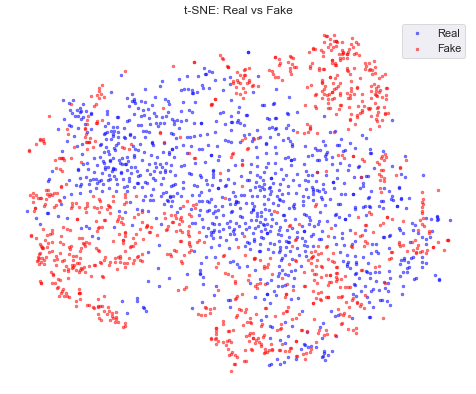

In [25]:
TSNE_SAMPLES = 1000

plot_tsne(generator, train_loader, latent_size, device, max_samples=TSNE_SAMPLES)

Прокомментируйте получившийся результат:

Есть небольшое перемешенивание классов.  
Однако точки, относящиеся к разным классам изображений (реальным и фейковым), все-таки собираются в кластеры.  
Следовательно реальные и фейковые изображения все еще различимы.